In [12]:
# Quasi-degenerate
import numpy as np
from Functions_Binned_Analysis import Discovery_Limit, IAXO, L_ES

def get_intersections_horizontal(x,y,y0):
    f = np.log(y)-np.log(y0)
    idx = np.where(np.sign(f[:-1])*np.sign(f[1:])<0)[0]
    x_cross = []
    lx = np.log(x)
    for k in idx:
        t = -f[k]/(f[k+1]-f[k])
        lx0 = lx[k]+t*(lx[k+1]-lx[k])
        x_cross.append(np.exp(lx0))
    return np.array(x_cross)

q0 = 9.0 # 3-sigma discovery limit
g_arb = 1.0e-11  # [GeV^-1]
mixing = np.pi/4.0
L_source = L_ES
w_min = 0.0 # [keV]
w_max = 20.0 # [keV]
N_bins = 200
res_on = True
w_res = 100e-3 # [keV]

# NuSTAR exclusion limit
NuSTAR = np.loadtxt("MyNuSTAR.dat")
m_NuSTAR = NuSTAR[:, 0]
g_ref_NuSTAR = NuSTAR[:, 1]

delta_m21_sq_vals = np.logspace(-16.0, -10.0, 100)
x = np.sqrt(delta_m21_sq_vals)

output = np.full((len(m_NuSTAR),3),np.nan)

for i,m2 in enumerate(m_NuSTAR):
    g_disc_for_NuSTAR = np.empty_like(delta_m21_sq_vals,dtype=float)
    for k,dm2 in enumerate(delta_m21_sq_vals):
        g_disc_for_NuSTAR[k] = Discovery_Limit(q0,g_arb,m2,dm2,
                                               mixing,IAXO["B"], IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],
                                               w_min,w_max,N_bins,
                                               res_on=res_on,w_res=w_res,
                                               m2_bounds=(m2,m2))

    x_cross = get_intersections_horizontal(x,g_disc_for_NuSTAR,g_ref_NuSTAR[i])
    if len(x_cross)>2:
        raise ValueError(f"More than two crossings for {m2:.6e}")
    output[i,0] = m2
    if len(x_cross)>=1:
        output[i,1] = x_cross[0]
    if len(x_cross)>=2:
        output[i,2] = x_cross[1]

np.savetxt("Mass-regimes/Quasi-degenerate/05to04.dat",output,fmt="%.6e",
           header="m1 [eV]    sqrt(Delta_m21_sq)_min [eV]    sqrt(Delta_m21_sq)_max [eV]")


In [14]:
# Quasi-degenerate
import numpy as np
from Functions_Binned_Analysis import Discovery_Limit, IAXO, L_ES

def get_intersections_horizontal(x,y,y0):
    f = np.log(y)-np.log(y0)
    idx = np.where(np.sign(f[:-1])*np.sign(f[1:])<0)[0]
    x_cross = []
    lx = np.log(x)
    for k in idx:
        t = -f[k]/(f[k+1]-f[k])
        lx0 = lx[k]+t*(lx[k+1]-lx[k])
        x_cross.append(np.exp(lx0))
    return np.array(x_cross)

q0 = 9.0 # 3-sigma discovery limit
g_arb = 1.0e-11  # [GeV^-1]
mixing = np.pi/4.0
L_source = L_ES
w_min = 0.0 # [keV]
w_max = 20.0 # [keV]
N_bins = 200
res_on = True
w_res = 100e-3 # [keV]

# HB exclusion limit
g_ref = 5.83e-11 # [GeV^-1]

delta_m21_sq_vals = np.logspace(-16.0,-10.0,100)
x = np.sqrt(delta_m21_sq_vals)
m_vals = np.logspace(np.log10(4e-4),-2,50)

output = np.full((len(m_vals),3),np.nan)

for i,m2 in enumerate(m_vals):
    g_disc = np.empty_like(delta_m21_sq_vals,dtype=float)
    for k,dm2 in enumerate(delta_m21_sq_vals):
        g_disc[k] = Discovery_Limit(q0,g_arb,m2,dm2,
                                    mixing,IAXO["B"], IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],
                                    w_min,w_max,N_bins,
                                    res_on=res_on,w_res=w_res,
                                    m2_bounds=(m2,m2))

    x_cross = get_intersections_horizontal(x,g_disc,g_ref)
    if len(x_cross)>2:
        raise ValueError(f"More than two crossings for {m2:.6e}")
    output[i,0] = m2
    if len(x_cross)>=1:
        output[i,1] = x_cross[0]
    if len(x_cross)>=2:
        output[i,2] = x_cross[1]

np.savetxt("Mass-regimes/Quasi-degenerate/04to02.dat",output,fmt="%.6e",
           header="m1 [eV]    sqrt(Delta_m21_sq)_min [eV]    sqrt(Delta_m21_sq)_max [eV]")


In [31]:
# Quasi-degenerate
import numpy as np
from Functions_Binned_Analysis import Discovery_Limit, IAXO, L_ES

def get_intersections_horizontal(x,y,y0):
    f = np.log(y)-np.log(y0)
    idx = np.where(np.sign(f[:-1])*np.sign(f[1:])<0)[0]
    x_cross = []
    lx = np.log(x)
    for k in idx:
        t = -f[k]/(f[k+1]-f[k])
        lx0 = lx[k]+t*(lx[k+1]-lx[k])
        x_cross.append(np.exp(lx0))
    return np.array(x_cross)

q0 = 9.0 # 3-sigma discovery limit
g_arb = 1.0e-11  # [GeV^-1]
mixing = np.pi/4.0
L_source = L_ES
w_min = 0.0 # [keV]
w_max = 20.0 # [keV]
N_bins = 200
res_on = True
w_res = 100e-3 # [keV]

# HB exclusion limit
g_ref = 5.83e-11 # [GeV^-1]

delta_m21_sq_vals = np.logspace(-16.0,-10.0,100)
x = np.sqrt(delta_m21_sq_vals)
m_vals = np.logspace(-2,np.log10(7e-2),50)

output = np.full((len(m_vals),3),np.nan)

for i,m2 in enumerate(m_vals):
    g_disc = np.empty_like(delta_m21_sq_vals,dtype=float)
    for k,dm2 in enumerate(delta_m21_sq_vals):
        g_disc[k] = Discovery_Limit(q0,g_arb,m2,dm2,
                                    mixing,IAXO["B"], IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],
                                    w_min,w_max,N_bins,
                                    res_on=res_on,w_res=w_res,
                                    m2_bounds=(m2,m2))

    x_cross = get_intersections_horizontal(x,g_disc,g_ref)
    if len(x_cross)>2:
        raise ValueError(f"More than two crossings for {m2:.6e}")
    output[i,0] = m2
    if len(x_cross)>=1:
        output[i,1] = x_cross[0]
    if len(x_cross)>=2:
        output[i,2] = x_cross[1]

np.savetxt("Mass-regimes/Quasi-degenerate/02to01.dat",output,fmt="%.6e",
           header="m1 [eV]    sqrt(Delta_m21_sq)_min [eV]    sqrt(Delta_m21_sq)_max [eV]")


In [32]:
# SN
import numpy as np
from Functions_Binned_Analysis import SN_Discovery_Limit, IAXO, L_SN

def get_intersections_horizontal(x,y,y0):
    f = np.log(y)-np.log(y0)
    idx = np.where(np.sign(f[:-1])*np.sign(f[1:])<0)[0]
    x_cross = []
    lx = np.log(x)
    for k in idx:
        t = -f[k]/(f[k+1]-f[k])
        lx0 = lx[k]+t*(lx[k+1]-lx[k])
        x_cross.append(np.exp(lx0))
    return np.array(x_cross)

g_aN = 1.3e-9
delta = 1.0
q0 = 9.0 # 3-sigma discovery limit
g_arb = 1.0e-11  # [GeV^-1]
mixing = np.pi/4.0
L_source = L_SN
eps = 0.95
w_min = 0.0 # [MeV]
w_max = 1000.0 # [MeV]
N_bins = 1000
res_on = True
w_res = 1 # [kMeV]

# NuSTAR exclusion limit
NuSTAR = np.loadtxt("MyNuSTAR.dat")
m_NuSTAR = NuSTAR[:, 0]
g_ref_NuSTAR = NuSTAR[:, 1]

delta_m21_sq_vals = np.logspace(-18.0,-14.0,100)
x = np.sqrt(delta_m21_sq_vals)

output = np.full((len(m_NuSTAR),3),np.nan)

for i,m2 in enumerate(m_NuSTAR):
    g_disc_for_NuSTAR = np.empty_like(delta_m21_sq_vals,dtype=float)
    for k,dm2 in enumerate(delta_m21_sq_vals):
        g_disc_for_NuSTAR[k] = SN_Discovery_Limit(g_aN,delta,q0,g_arb,m2,dm2,
                                                  mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],eps,
                                                  w_min,w_max,N_bins,
                                                  res_on=res_on,w_res=w_res,
                                                  m2_bounds=(m2,m2))

    x_cross = get_intersections_horizontal(x,g_disc_for_NuSTAR,g_ref_NuSTAR[i])
    if len(x_cross)>2:
        raise ValueError(f"More than two crossings for {m2:.6e}")
    output[i,0] = m2
    if len(x_cross)>=1:
        output[i,1] = x_cross[0]
    if len(x_cross)>=2:
        output[i,2] = x_cross[1]

np.savetxt("Mass-regimes/SN/05to04.dat",output,fmt="%.6e",
           header="m1 [eV]    sqrt(Delta_m21_sq)_min [eV]    sqrt(Delta_m21_sq)_max [eV]")

In [36]:
# SN
import numpy as np
from Functions_Binned_Analysis import SN_Discovery_Limit, IAXO, L_SN

def get_intersections_horizontal(x,y,y0):
    f = np.log(y)-np.log(y0)
    idx = np.where(np.sign(f[:-1])*np.sign(f[1:])<0)[0]
    x_cross = []
    lx = np.log(x)
    for k in idx:
        t = -f[k]/(f[k+1]-f[k])
        lx0 = lx[k]+t*(lx[k+1]-lx[k])
        x_cross.append(np.exp(lx0))
    return np.array(x_cross)

g_aN = 1.3e-9
delta = 1.0
q0 = 9.0 # 3-sigma discovery limit
g_arb = 1.0e-11  # [GeV^-1]
mixing = np.pi/4.0
L_source = L_SN
eps = 0.95
w_min = 0.0 # [MeV]
w_max = 1000.0 # [MeV]
N_bins = 1000
res_on = True
w_res = 1 # [kMeV]

# HB exclusion limit
g_ref = 5.83e-11 # [GeV^-1]

delta_m21_sq_vals = np.logspace(-18.0,-14.0,100)
x = np.sqrt(delta_m21_sq_vals)
m_vals = np.logspace(np.log10(4e-4),-1,10)

output = np.full((len(m_vals),3),np.nan)

for i,m2 in enumerate(m_vals):
    g_disc = np.empty_like(delta_m21_sq_vals,dtype=float)
    for k,dm2 in enumerate(delta_m21_sq_vals):
        g_disc[k] = SN_Discovery_Limit(g_aN,delta,q0,g_arb,m2,dm2,
                                       mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],eps,
                                       w_min,w_max,N_bins,
                                       res_on=res_on,w_res=w_res,
                                       m2_bounds=(m2,m2))

    x_cross = get_intersections_horizontal(x,g_disc,g_ref)
    if len(x_cross)>2:
        raise ValueError(f"More than two crossings for {m2:.6e}")
    output[i,0] = m2
    if len(x_cross)>=1:
        output[i,1] = x_cross[0]
    if len(x_cross)>=2:
        output[i,2] = x_cross[1]

np.savetxt("Mass-regimes/SN/04to01.dat",output,fmt="%.6e",
           header="m1 [eV]    sqrt(Delta_m21_sq)_min [eV]    sqrt(Delta_m21_sq)_max [eV]")

In [64]:
# Hierarchical
import numpy as np
from Functions_Binned_Analysis import Discovery_Limit, IAXO, L_ES

def get_intersections_horizontal(x,y,y0):
    f = np.log(y)-np.log(y0)
    idx = np.where(np.sign(f[:-1])*np.sign(f[1:])<0)[0]
    x_cross = []
    lx = np.log(x)
    for k in idx:
        t = -f[k]/(f[k+1]-f[k])
        lx0 = lx[k]+t*(lx[k+1]-lx[k])
        x_cross.append(np.exp(lx0))
    return np.array(x_cross)

q0 = 9.0 # 3-sigma discovery limit
g_arb = 1.0e-11  # [GeV^-1]
mixing = np.pi/4.0
L_source = L_ES
w_min = 0.0 # [keV]
w_max = 20.0 # [keV]
N_bins = 200
res_on = True
w_res = 100e-3 # [keV]

# NuSTAR exclusion limit
NuSTAR = np.loadtxt("MyNuSTAR.dat")
m_NuSTAR = NuSTAR[:, 0]
g_ref_NuSTAR = NuSTAR[:,1]

delta_m21_sq_vals = np.logspace(-6.0,-2.0,100)
x = np.sqrt(delta_m21_sq_vals)

output = np.full((len(m_NuSTAR),3),np.nan)

g_disc_for_NuSTAR = np.empty_like(delta_m21_sq_vals,dtype=float)
for k,dm2 in enumerate(delta_m21_sq_vals):
    m2 = (1+1e-10)*np.sqrt(dm2)
    g_disc_for_NuSTAR[k] = Discovery_Limit(q0,g_arb,m2,dm2,
                                           mixing,IAXO["B"], IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],
                                           w_min,w_max,N_bins,
                                           res_on=res_on,w_res=w_res,
                                           m2_bounds=(1e-9,1e0))

for i,m1 in enumerate(m_NuSTAR):
    x_cross = get_intersections_horizontal(x,g_disc_for_NuSTAR,g_ref_NuSTAR[i])
    if len(x_cross)>2:
        raise ValueError(f"More than two crossings for {m1:.6e}")
    output[i,0] = m1
    if len(x_cross)>=1:
        output[i,1] = x_cross[0]
    if len(x_cross)>=2:
        output[i,2] = x_cross[1]

np.savetxt("Mass-regimes/Hierarchical/05to04.dat",output,fmt="%.6e",
           header="m1 [eV]    sqrt(Delta_m21_sq)_min [eV]    sqrt(Delta_m21_sq)_max [eV]")


In [5]:
# Hierarchical
import numpy as np
from Functions_Binned_Analysis import Discovery_Limit, IAXO, L_ES

def get_intersections_horizontal(x,y,y0):
    f = np.log(y)-np.log(y0)
    idx = np.where(np.sign(f[:-1])*np.sign(f[1:])<0)[0]
    x_cross = []
    lx = np.log(x)
    for k in idx:
        t = -f[k]/(f[k+1]-f[k])
        lx0 = lx[k]+t*(lx[k+1]-lx[k])
        x_cross.append(np.exp(lx0))
    return np.array(x_cross)

q0 = 9.0 # 3-sigma discovery limit
g_arb = 1.0e-11  # [GeV^-1]
mixing = np.pi/4.0
L_source = L_ES
w_min = 0.0 # [keV]
w_max = 20.0 # [keV]
N_bins = 200
res_on = True
w_res = 100e-3 # [keV]

# HB exclusion limit
g_ref = 5.83e-11 # [GeV^-1]

delta_m21_sq_vals = np.logspace(-6.0,-2.0,100)
x = np.sqrt(delta_m21_sq_vals)
m_vals = np.logspace(np.log10(4e-4),np.log10(2.5e-3),10)

output = np.full((len(m_vals),3),np.nan)

g_disc = np.empty_like(delta_m21_sq_vals,dtype=float)
for k,dm2 in enumerate(delta_m21_sq_vals):
    m2 = (1+1e-10)*np.sqrt(dm2)
    g_disc[k] = Discovery_Limit(q0,g_arb,m2,dm2,
                                mixing,IAXO["B"], IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],
                                w_min,w_max,N_bins,
                                res_on=res_on,w_res=w_res,
                                m2_bounds=(1e-9,1e0))

for i,m1 in enumerate(m_vals):
    x_cross = get_intersections_horizontal(x,g_disc,g_ref)
    if len(x_cross)>2:
        raise ValueError(f"More than two crossings for {m1:.6e}")
    output[i,0] = m1
    if len(x_cross)>=1:
        output[i,1] = x_cross[0]
    if len(x_cross)>=2:
        output[i,2] = x_cross[1]

np.savetxt("Mass-regimes/Hierarchical/04to03.dat",output,fmt="%.6e",
           header="m1 [eV]    sqrt(Delta_m21_sq)_min [eV]    sqrt(Delta_m21_sq)_max [eV]")


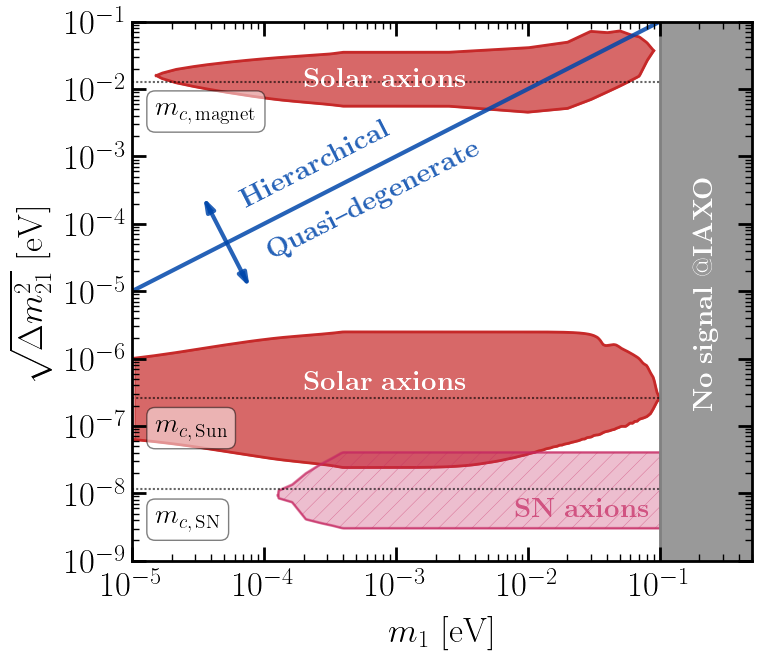

In [2]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from palettable.colorbrewer.sequential import YlOrRd_5
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

plt.rcParams.update({
   "text.usetex":True,
   "font.size":25,
   "axes.formatter.limits":[-3,3],
   "axes.linewidth":2,
   "lines.linewidth":2,
   "hatch.linewidth":0.3,
   "xtick.top":True,
   "xtick.bottom":True,
   "ytick.left":True,
   "ytick.right":True,
   "xtick.minor.visible":True,
   "ytick.minor.visible":True,
   "xtick.direction":"in",
   "ytick.direction":"in",
   "xtick.major.width":2,
   "xtick.minor.width":1,
   "ytick.major.width":2,
   "ytick.minor.width":1,
   "xtick.major.size":10,
   "xtick.minor.size":5,
   "ytick.major.size":10,
   "ytick.minor.size":5,
   "figure.figsize":[8,7],
   "savefig.dpi":300,
   "savefig.transparent":True
})

colors_reds = YlOrRd_5.mpl_colors

gs = gridspec.GridSpec(1,1,wspace=0.0)
fig = plt.figure()
ax = fig.add_subplot(gs[0])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(left=1e-5,right=5e-1)
ax.set_ylim(bottom=1e-9,top=1e-1)
ax.set_yticks([1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1])
ax.set_yticklabels([r"$10^{-9}$",r"$10^{-8}$",r"$10^{-7}$",r"$10^{-6}$",r"$10^{-5}$",r"$10^{-4}$",r"$10^{-3}$",r"$10^{-2}$",r"$10^{-1}$"])
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0,subs=np.arange(2,10),numticks=100))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.xaxis.set_zorder(1000)
ax.yaxis.set_zorder(1000)
x_min,x_max = ax.get_xlim()
y_min,y_max = ax.get_ylim()
ax.tick_params(axis='x',which='major',pad=8)
ax.tick_params(axis='x',which='minor',pad=8)
ax.set_xlabel(r"$m_1\ [\mathrm{eV}]$",labelpad=10)
ax.set_ylabel(r"$\sqrt{\Delta m_{21}^2}\ [\mathrm{eV}]$",labelpad=10)

# No signal @IAXO
m_max = 1e-1 # [eV]
ax.axvline(m_max,color='gray',lw=2)
ax.axvspan(m_max,x_max,color='gray',alpha=0.8)
ax.text(1.8e-1,2e-7,r'$\mathrm{\bf No\ signal\ @IAXO}$',rotation=90,color='white',fontsize=20,zorder=100)

# Critical mass magnet
m_crit = 0.012865681906181361 # [eV]
ax.hlines(m_crit,xmin=x_min,xmax=m_max,colors='black',ls=(0,(1,1)),lw=1.5,alpha=0.6)
ax.text(1.5e-5,4e-3,r'$m_{c,\,\mathrm{magnet}}$',color='black',fontsize=20,
        bbox=dict(boxstyle='round,pad=0.3',facecolor='white',edgecolor='black',alpha=0.5)
       )

# Critical mass Sun
m_crit = 2.633159182107855e-07 # [eV]
ax.hlines(m_crit,xmin=x_min,xmax=m_max,colors='black',ls=(0,(1,1)),lw=1.5,alpha=0.6)
ax.text(1.5e-5,8e-8,r'$m_{c,\,\mathrm{Sun}}$',color='black',fontsize=20,
        bbox=dict(boxstyle='round,pad=0.3',facecolor='white',edgecolor='black',alpha=0.5)
       )

# Critical mass SN
m_crit = 1.1445153378370164e-08 # [eV]
ax.hlines(m_crit,xmin=x_min,xmax=m_max,colors='black',ls=(0,(1,1)),lw=1.5,alpha=0.6)
ax.text(1.5e-5,3.5e-9,r'$m_{c,\,\mathrm{SN}}$',color='black',fontsize=20,
        bbox=dict(boxstyle='round,pad=0.3',facecolor='white',edgecolor='black',alpha=0.5)
       )

# Diagonal
ax.plot(np.logspace(np.log(x_min),1e-1,3),np.logspace(np.log(x_min),1e-1,3),color="#0047AB",alpha=0.85,lw=3)
ax.text(1e-4,3e-5,r'$\mathrm{\bf Quasi}$--$\mathrm{\bf degenerate}$',color="#0047AB",alpha=0.85,rotation=27,fontsize=20)
ax.text(6.3e-5,1.8e-4,r'$\mathrm{\bf Hierarchical}$',color="#0047AB",alpha=0.85,rotation=27,fontsize=20)
x_start = 3.4e-5
y_start = 2.7e-4
x_end = 7.98e-5
y_end = 1.05e-5
ax.annotate("",xy=(x_end,y_end),xytext=(x_start,y_start),
            arrowprops=dict(arrowstyle='<|-|>,head_length=0.3,head_width=0.1',color="#0047AB",alpha=0.85,lw=3)
           )

def plot_interp_loglog(ax,xdat,ydat,n=300,**plot_kw):
    m = np.isfinite(xdat) & np.isfinite(ydat) & (xdat > 0) & (ydat > 0)
    x = xdat[m]
    y = ydat[m]
    if x.size < 2:
        return
    s = np.argsort(x)
    x = x[s]
    y = y[s]
    lx = np.log10(x)
    ly = np.log10(y)
    x_new = np.geomspace(x.min(),x.max(),n)
    y_new = 10.0**np.interp(np.log10(x_new),lx,ly)
    ax.plot(x_new,y_new,**plot_kw)

# Solar axions: quasi-degenerate regime
data = np.loadtxt("results_data/Mass-regimes/Quasi-degenerate/Quasi-degenerate_regime.dat")
m1 = data[:,0]
cross_1 = data[:,1]
cross_2 = data[:,2]
plot_interp_loglog(ax,m1,cross_1,n=400,color='#C62828',alpha=0.99,zorder=0)
plot_interp_loglog(ax,m1,cross_2,n=400,color='#C62828',alpha=0.99,zorder=0)
ax.fill_between(m1,cross_1,cross_2,color='#C62828',alpha=0.7,zorder=0)
ax.text(2e-4,3.5e-7,r'$\mathrm{\bf Solar\ axions}$',color='white',fontsize=20)

# SN axions: quasi-degenerate regime
data = np.loadtxt("results_data/Mass-regimes/SN/SN_regime.dat")
m1 = data[:,0]
cross_1 = data[:,1]
cross_2 = data[:,2]
plot_interp_loglog(ax,m1,cross_1,n=400,color='#C62862',alpha=0.5,lw=2,zorder=0)
plot_interp_loglog(ax,m1,cross_2,n=400,color='#C62862',alpha=0.5,lw=2,zorder=0)
ax.fill_between(m1,cross_1,cross_2,color="#C62862",alpha=0.3,zorder=0)
ax.fill_between(
    m1, cross_1, cross_2,
    facecolor="none",
    edgecolor="#C62862",
    hatch="//",
    alpha=0.6,
    zorder=0
)
ax.text(8e-3,4.5e-9,r'$\mathrm{\bf SN\ axions}$',color='#C62862',alpha=0.7,fontsize=20,zorder=0.1)

# Solar axions: hierarchical regime
data = np.loadtxt("results_data/Mass-regimes/Hierarchical/Hierarchical_regime.dat")
m1 = data[:,0]
cross_1 = data[:,1]
cross_2 = data[:,2]
plot_interp_loglog(ax,m1,cross_1,n=400,color='#C62828',alpha=0.99,zorder=0)
plot_interp_loglog(ax,m1,cross_2,n=400,color='#C62828',alpha=0.99,zorder=0)
ax.fill_between(m1,cross_1,cross_2,color='#C62828',alpha=0.7,zorder=0)
ax.text(2e-4,1.1e-2,r'$\mathrm{\bf Solar\ axions}$',color='white',fontsize=20)

fig.savefig("plots/Regimes.pdf",bbox_inches="tight")
fig.savefig("plots/Regimes.png",bbox_inches="tight")
plt.show()